- 데이터: `../results/emnist`에 이미 캐시된 EMNIST ByClass를 그대로 재사용하되(재다운로드 없음),
  거기서 소문자를 제외시켜서 대문자+숫자인 총 36 class 사용
- hyperparameters: batch 128, epoch 10, Adam lr=0.001(betas 기본값), seed 261014
- 목표: XC7Z020 BRAM 630KB(645,120B) 예산 안에 들어오는 조합을 정확도와 함께 비교
- 실행 위치: `tb`에서 커널을 띄운다 (`lightletter-tb`/venv 커널 선택)

In [9]:
from pathlib import Path

import numpy as np
import torch
from torch.nn import functional as F
from torchvision.datasets import EMNIST

DATA_ROOT = Path('../results/emnist')
BRAM_BUDGET_BYTES = 630 * 1024  # XC7Z020, weight-only 하한과 비교하는 예산
NUM_CLASSES = 36
SEED = 261014
BATCH_SIZE = 128
EPOCHS = 10
LR = .001
DEVICE = 'mps' if torch.backends.mps.is_available() else 'cpu'
print('device:', DEVICE)


def load_split(partition):
    dataset = EMNIST(root=str(DATA_ROOT), split='byclass', train=(partition == 'train'), download=True)
    images = dataset.data.numpy()
    labels = dataset.targets.numpy()
    images = np.transpose(images, (0, 2, 1))  # EMNIST 회전+반전 아티팩트 보정
    keep = labels < NUM_CLASSES
    return images[keep].copy(), labels[keep].astype(np.int64).copy()


x_train, y_train = load_split('train')
x_test, y_test = load_split('test')

VAL_FRACTION = 0.1  # train에서 검증용으로 떼어두는 비율 -- test는 최종 1회 평가 전까지 절대 안 봄
_perm = np.random.default_rng(SEED).permutation(len(y_train))
_val_size = int(len(y_train) * VAL_FRACTION)
val_ids, train_ids = _perm[:_val_size], _perm[_val_size:]
x_val, y_val = x_train[val_ids], y_train[val_ids]
x_train, y_train = x_train[train_ids], y_train[train_ids]

print('train:', x_train.shape, 'val:', x_val.shape, 'test:', x_test.shape)

device: mps
train: (480594, 28, 28) val: (53399, 28, 28) test: (89264, 28, 28)


## 모델 파라미터화

`model.py`의 `Net`/`Quant16`을 그대로 옮기되, `conv_channels`·`padding`·
`pool_stride`·`fc_widths`를 생성자 인자로 받게 해서 조합을 변경 가능
kernel(3x3)·pool kernel(2x2)·activation(ReLU)·양자화(INT16 QAT)

In [10]:
from torch import nn
class Quant16(nn.Module):
    """대칭 signed INT16 fake-quantization. tb/cnn_golden/model.py와 동일."""
    def __init__(self, weight=False):
        super().__init__()
        self.weight = weight
        self.enabled = True
        self.register_buffer('maximum', torch.tensor(0.))

    @property
    def scale(self):
        return 2. ** torch.ceil(torch.log2(self.maximum.clamp_min(1e-12) / 32767.))

    def forward(self, x):
        if not self.enabled:
            return x
        if self.training:
            with torch.no_grad():
                maximum = x.detach().abs().amax()
                self.maximum.copy_(maximum if self.weight else torch.maximum(self.maximum, maximum))
        scale = self.scale.detach()
        clipped = (x / scale).clamp(-32768, 32767)
        rounded = clipped + (clipped.round() - clipped).detach()
        return rounded * scale


class Net(nn.Module):
    def __init__(self, conv_channels, padding, pool_stride, fc_widths):
        super().__init__()
        self.conv_channels = conv_channels
        self.padding = padding
        self.pool_stride = pool_stride
        self.convs = nn.ModuleList([
            nn.Conv2d(conv_channels[i], conv_channels[i + 1], 3, padding=padding)
            for i in range(len(conv_channels) - 1)
        ])
        size = 28
        self.sizes = []
        for _ in self.convs:
            size = size - 2 + 2 * padding
            size = (size - 2) // pool_stride + 1
            if size < 1:
                raise ValueError('Empty spatial output')
            self.sizes.append(size)
        widths = [conv_channels[-1] * size * size] + list(fc_widths)
        self.fcs = nn.ModuleList([nn.Linear(a, b) for a, b in zip(widths, widths[1:])])
        self.input_quant = Quant16()
        self.weight_quant = nn.ModuleList([Quant16(weight=True) for _ in [*self.convs, *self.fcs]])
        self.activation_quant = nn.ModuleList([Quant16() for _ in [*self.convs, *self.fcs]])

    def quantization(self, enabled):
        for module in self.modules():
            if isinstance(module, Quant16):
                module.enabled = enabled

    def forward(self, x):
        x = self.input_quant(x)
        for i, conv in enumerate(self.convs):
            x = F.conv2d(x, self.weight_quant[i](conv.weight), conv.bias, padding=self.padding)
            x = self.activation_quant[i](F.relu(x))
            x = F.max_pool2d(x, 2, self.pool_stride)
        x = x.flatten(1)
        for j, fc in enumerate(self.fcs):
            i = len(self.convs) + j
            x = F.linear(x, self.weight_quant[i](fc.weight), fc.bias)
            if j < len(self.fcs) - 1:
                x = F.relu(x)
            x = self.activation_quant[i](x)
        return x

    def inventory(self):
        weights = sum(m.weight.numel() for m in [*self.convs, *self.fcs])
        biases = sum(m.bias.numel() for m in [*self.convs, *self.fcs])
        weight_bytes = weights * 2
        return dict(weights=weights, biases=biases, weight_int16_bytes=weight_bytes,
                    bram_ratio=weight_bytes / BRAM_BUDGET_BYTES,
                    spatial_outputs=self.sizes)


In [11]:
def batch(x, ids, device):
    return torch.from_numpy(np.asarray(x[ids, None], dtype=np.float32) / 255.).to(device)


@torch.no_grad()
def predict(net, x, device):
    net.eval()
    result = []
    for offset in range(0, len(x), BATCH_SIZE):
        result.append(net(batch(x, slice(offset, offset + BATCH_SIZE), device)).argmax(1).cpu().numpy())
    return np.concatenate(result)


def scores(labels, predictions):
    cm = np.bincount(labels * 36 + predictions, minlength=36 * 36).reshape(36, 36)
    return dict(accuracy=float(np.mean(labels == predictions)),
                digit_accuracy=float(np.mean(labels[labels < 10] == predictions[labels < 10])),
                letter_accuracy=float(np.mean(labels[labels >= 10] == predictions[labels >= 10])),
                balanced_accuracy=float(np.mean(cm.diagonal() / cm.sum(1))))


## 최종 타깃 후보 확정 — 1-6-16, padding=0, pool_stride=1, FC1=256, INT16

FC는 당장은 PS(ARM)에서 소프트웨어로 처리하고, 향후 Conv(FRCE)에 시간 여유가 생기면 FC도
PL로 옮겨 WRCE를 적용하는 것을 염두에 두고 있다. 이 시나리오에서 가장 유력한 후보로
`conv_channels=[1,6,16]`, `padding=0`, `pool_stride=1`, `fc_widths=[128,64,36]`, INT16을 정했다
(24개 조합 스윕 중 `ps1_fc128_c16_b16`에 해당 — 이전 15epoch 결과는 `results/sweep_24.json`에
남아있다).

이 후보를 **50epoch까지 학습**해서 loss·정확도가 0~50 구간에서 어떻게 움직이는지 전체
그래프로 확인한다. 이전에 관찰한 "문자 정확도가 15epoch보다 이른 epoch(3 근처)에서 더 높았던"
패턴이 50epoch까지 봤을 때도 유지되는지, 더 긴 학습에서 회복되는지를 본다.


**평가 방식**: train에서 10%를 validation으로 떼어내(`VAL_FRACTION`), 매 epoch은 validation으로만 추적한다. test는 학습이 끝난 뒤 (1) 마지막 epoch, (2) validation 문자 정확도가 제일 높았던 epoch, 이 두 시점에 대해서만 각각 한 번씩 평가한다 — epoch마다 test를 들여다보면 사실상 test로 "몇 epoch이 좋은지"를 고르는 셈이 되어 결과가 낙관적으로 왜곡된다.

In [12]:
import copy
import json
from pathlib import Path

TARGET_RESULTS_PATH = Path('/Users/mumallaeng/repo/activity/LightLetter/tb/cnn_golden/results/target_1_6_16_int16_50ep.json')


def train_target_with_history(conv_channels, padding, pool_stride, fc_widths, epochs, device=DEVICE,
                               save_path=TARGET_RESULTS_PATH):
    """매 epoch은 validation으로만 추적한다. test는 학습이 완전히 끝난 뒤 두 시점(마지막 epoch,
    validation 문자 정확도가 제일 높았던 epoch)에 대해 딱 한 번씩만 평가한다 -- epoch마다 test를
    들여다보면 'best epoch 선택'이 사실상 test 데이터로 하이퍼파라미터를 고르는 셈이 되어버린다."""
    counts = np.bincount(y_train, minlength=36)
    letter_weight = float(counts[:10].sum() / counts[10:].sum())
    class_weights = torch.ones(36, device=device)
    class_weights[10:] = letter_weight

    torch.manual_seed(SEED)
    net = Net(conv_channels, padding, pool_stride, fc_widths).to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=LR)

    history = []
    best_val_letter = -1.
    best_state = None
    best_epoch = None
    for epoch in range(epochs):
        net.train()
        order = np.random.default_rng(SEED + epoch).permutation(len(y_train))
        total = 0.
        for offset in range(0, len(y_train), BATCH_SIZE):
            ids = order[offset:offset + BATCH_SIZE]
            target = torch.from_numpy(np.array(y_train[ids])).to(device)
            optimizer.zero_grad(set_to_none=True)
            loss = F.cross_entropy(net(batch(x_train, ids, device)), target, weight=class_weights)
            loss.backward()
            optimizer.step()
            total += loss.item() * len(ids)
        train_loss = total / len(y_train)
        val_scores = scores(y_val, predict(net, x_val, device))
        history.append(dict(epoch=epoch + 1, loss=train_loss,
                             val_accuracy=val_scores["accuracy"],
                             val_digit_accuracy=val_scores["digit_accuracy"],
                             val_letter_accuracy=val_scores["letter_accuracy"],
                             val_balanced_accuracy=val_scores["balanced_accuracy"]))
        print(f"epoch {epoch + 1}/{epochs} loss={train_loss:.4f} "
              f"val_acc={val_scores['accuracy']:.4f} val_digit={val_scores['digit_accuracy']:.4f} "
              f"val_letter={val_scores['letter_accuracy']:.4f} val_balanced={val_scores['balanced_accuracy']:.4f}")
        if val_scores["letter_accuracy"] > best_val_letter:
            best_val_letter = val_scores["letter_accuracy"]
            best_epoch = epoch + 1
            best_state = copy.deepcopy(net.state_dict())
        save_path.parent.mkdir(parents=True, exist_ok=True)
        save_path.write_text(json.dumps(dict(history=history, best_epoch=best_epoch,
                                              best_val_letter_accuracy=best_val_letter),
                                         indent=2, ensure_ascii=False))

    # test는 여기서 딱 두 번만 -- 마지막 epoch 가중치, 그리고 validation 기준 best epoch 가중치
    final_test = scores(y_test, predict(net, x_test, device))
    net.load_state_dict(best_state)
    best_test = scores(y_test, predict(net, x_test, device))

    print()
    print(f"final epoch({epochs}) test:", {k: round(v, 4) for k, v in final_test.items()})
    print(f"best val epoch({best_epoch}) test:", {k: round(v, 4) for k, v in best_test.items()})

    save_path.write_text(json.dumps(dict(history=history, best_epoch=best_epoch,
                                          best_val_letter_accuracy=best_val_letter,
                                          final_epoch_test=final_test, best_val_epoch_test=best_test),
                                     indent=2, ensure_ascii=False))
    return net, history, dict(best_epoch=best_epoch, final_epoch_test=final_test, best_val_epoch_test=best_test)


In [14]:
import time
_start = time.time()
net_target, history_target, test_target = train_target_with_history(
    conv_channels=[1, 6, 16], padding=0, pool_stride=1, fc_widths=[256, 64, 36], epochs=50)
_elapsed = time.time() - _start
inv_target = net_target.inventory()
print()
print(f"총 소요시간: {_elapsed:.1f}초 ({_elapsed/50:.1f}초/epoch)")
print("weights:", inv_target["weights"], "bytes:", inv_target["weight_int16_bytes"],
      f"BRAM 배율(630KB): {inv_target['bram_ratio']:.3f}x")
print(f"best val epoch: {test_target['best_epoch']}")
print("best val epoch test:", {k: round(v, 4) for k, v in test_target["best_val_epoch_test"].items()})
print("final epoch(50) test:", {k: round(v, 4) for k, v in test_target["final_epoch_test"].items()})

epoch 1/50 loss=0.3980 val_acc=0.9132 val_digit=0.9379 val_letter=0.8680 val_balanced=0.9075
epoch 2/50 loss=0.2368 val_acc=0.9049 val_digit=0.9050 val_letter=0.9047 val_balanced=0.9132
epoch 3/50 loss=0.2119 val_acc=0.9220 val_digit=0.9395 val_letter=0.8899 val_balanced=0.9216
epoch 4/50 loss=0.1947 val_acc=0.9247 val_digit=0.9457 val_letter=0.8864 val_balanced=0.9197
epoch 5/50 loss=0.1816 val_acc=0.9240 val_digit=0.9438 val_letter=0.8879 val_balanced=0.9241
epoch 6/50 loss=0.1715 val_acc=0.9214 val_digit=0.9333 val_letter=0.8996 val_balanced=0.9218
epoch 7/50 loss=0.1631 val_acc=0.9234 val_digit=0.9384 val_letter=0.8960 val_balanced=0.9268
epoch 8/50 loss=0.1560 val_acc=0.9218 val_digit=0.9298 val_letter=0.9071 val_balanced=0.9301
epoch 9/50 loss=0.1500 val_acc=0.9239 val_digit=0.9398 val_letter=0.8946 val_balanced=0.9239
epoch 10/50 loss=0.1445 val_acc=0.9260 val_digit=0.9479 val_letter=0.8860 val_balanced=0.9271
epoch 11/50 loss=0.1394 val_acc=0.9224 val_digit=0.9413 val_letter=0.

## 0~50 epoch 전체 그래프

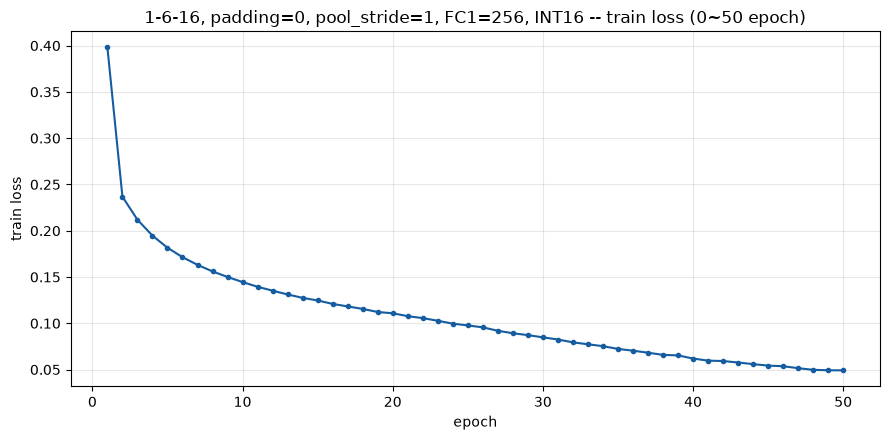

In [15]:
import matplotlib.pyplot as plt

epochs_x = [h["epoch"] for h in history_target]
plt.figure(figsize=(9, 4.5))
plt.plot(epochs_x, [h["loss"] for h in history_target], marker="o", markersize=3, color="#155ca1")
plt.xlabel("epoch")
plt.ylabel("train loss")
plt.title("1-6-16, padding=0, pool_stride=1, FC1=256, INT16 -- train loss (0~50 epoch)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("results/target_loss_curve.png", dpi=150)
plt.show()


/var/folders/1k/qd45bt3d32b89dxbqgz7l01r0000gn/T/ipykernel_85755/1408509861.py:16: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1k/qd45bt3d32b89dxbqgz7l01r0000gn/T/ipykernel_85755/1408509861.py:16: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1k/qd45bt3d32b89dxbqgz7l01r0000gn/T/ipykernel_85755/1408509861.py:16: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1k/qd45bt3d32b89dxbqgz7l01r0000gn/T/ipykernel_85755/1408509861.py:16: UserWarning: Glyph 47564 (\N{HANGUL SYLLABLE MAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1k/qd45bt3d32b89dxbqgz7l01r0000gn/T/ipykernel_85755/1408509861.py:16: UserWarning: Glyph 46160 (\N{HANGUL SYLLABLE DU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1k/qd45bt3d32b89dxbqgz7l01r0000gn/T/ipyk

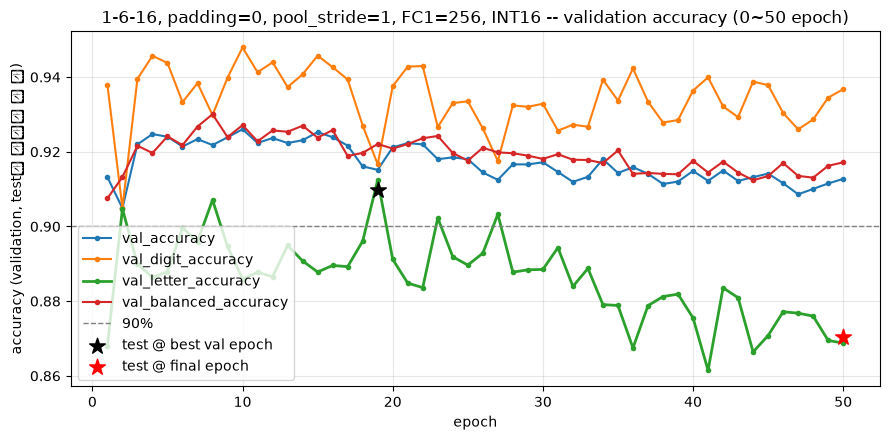

In [16]:
plt.figure(figsize=(9, 4.5))
plt.plot(epochs_x, [h["val_accuracy"] for h in history_target], label="val_accuracy", marker="o", markersize=3)
plt.plot(epochs_x, [h["val_digit_accuracy"] for h in history_target], label="val_digit_accuracy", marker="o", markersize=3)
plt.plot(epochs_x, [h["val_letter_accuracy"] for h in history_target], label="val_letter_accuracy", marker="o", markersize=3, linewidth=2)
plt.plot(epochs_x, [h["val_balanced_accuracy"] for h in history_target], label="val_balanced_accuracy", marker="o", markersize=3)
plt.axhline(0.90, color="gray", linestyle="--", linewidth=1, label="90%")
plt.scatter([test_target["best_epoch"]], [test_target["best_val_epoch_test"]["letter_accuracy"]],
            color="black", zorder=5, marker="*", s=140, label="test @ best val epoch")
plt.scatter([50], [test_target["final_epoch_test"]["letter_accuracy"]],
            color="red", zorder=5, marker="*", s=140, label="test @ final epoch")
plt.xlabel("epoch")
plt.ylabel("accuracy (validation, test는 별표만 두 점)")
plt.title("1-6-16, padding=0, pool_stride=1, FC1=256, INT16 -- validation accuracy (0~50 epoch)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("results/target_accuracy_curve.png", dpi=150)
plt.show()


## conv 3-layer 비교 — 1-6-8-8, padding=0, pool_stride=1, FC1=256, INT16, 50epoch

conv layer 3개(`conv_channels=[1,6,8,8]`)로 같은 조건에서 50epoch 학습해서, 2-layer(1-6-16)와
loss·정확도 추세(특히 문자 정확도가 계속 나빠지는 패턴이 여기서도 나오는지)를 비교한다.


In [ ]:
_start = time.time()
net_3layer, history_3layer, test_3layer = train_target_with_history(
    conv_channels=[1, 6, 8, 8], padding=0, pool_stride=1, fc_widths=[256, 64, 36], epochs=50,
    save_path=Path('/Users/mumallaeng/repo/activity/LightLetter/tb/cnn_golden/results/target_1_6_8_8_int16_50ep.json'))
_elapsed = time.time() - _start
inv_3layer = net_3layer.inventory()
print()
print(f"총 소요시간: {_elapsed:.1f}초 ({_elapsed/50:.1f}초/epoch)")
print("spatial_outputs:", inv_3layer["spatial_outputs"])
print("weights:", inv_3layer["weights"], "bytes:", inv_3layer["weight_int16_bytes"],
      f"BRAM 배율(630KB): {inv_3layer['bram_ratio']:.3f}x")
print(f"best val epoch: {test_3layer['best_epoch']}")
print("best val epoch test:", {k: round(v, 4) for k, v in test_3layer["best_val_epoch_test"].items()})
print("final epoch(50) test:", {k: round(v, 4) for k, v in test_3layer["final_epoch_test"].items()})

epoch 1/50 loss=0.4508 val_acc=0.9058 val_digit=0.9253 val_letter=0.8702 val_balanced=0.8997
epoch 2/50 loss=0.2576 val_acc=0.8965 val_digit=0.8889 val_letter=0.9102 val_balanced=0.9068
epoch 3/50 loss=0.2318 val_acc=0.9177 val_digit=0.9384 val_letter=0.8798 val_balanced=0.9149
epoch 4/50 loss=0.2171 val_acc=0.9202 val_digit=0.9465 val_letter=0.8721 val_balanced=0.9127


### 1-6-8-8 그래프 (0~50 epoch)

In [ ]:
epochs_x3 = [h["epoch"] for h in history_3layer]
plt.figure(figsize=(9, 4.5))
plt.plot(epochs_x3, [h["loss"] for h in history_3layer], marker="o", markersize=3, color="#155ca1")
plt.xlabel("epoch")
plt.ylabel("train loss")
plt.title("1-6-8-8, padding=0, pool_stride=1, FC1=256, INT16 -- train loss (0~50 epoch)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("results/target_3layer_loss_curve.png", dpi=150)
plt.show()


In [ ]:
plt.figure(figsize=(9, 4.5))
plt.plot(epochs_x3, [h["val_accuracy"] for h in history_3layer], label="val_accuracy", marker="o", markersize=3)
plt.plot(epochs_x3, [h["val_digit_accuracy"] for h in history_3layer], label="val_digit_accuracy", marker="o", markersize=3)
plt.plot(epochs_x3, [h["val_letter_accuracy"] for h in history_3layer], label="val_letter_accuracy", marker="o", markersize=3, linewidth=2)
plt.plot(epochs_x3, [h["val_balanced_accuracy"] for h in history_3layer], label="val_balanced_accuracy", marker="o", markersize=3)
plt.axhline(0.90, color="gray", linestyle="--", linewidth=1, label="90%")
plt.scatter([test_3layer["best_epoch"]], [test_3layer["best_val_epoch_test"]["letter_accuracy"]],
            color="black", zorder=5, marker="*", s=140, label="test @ best val epoch")
plt.scatter([50], [test_3layer["final_epoch_test"]["letter_accuracy"]],
            color="red", zorder=5, marker="*", s=140, label="test @ final epoch")
plt.xlabel("epoch")
plt.ylabel("accuracy (validation, test는 별표만 두 점)")
plt.title("1-6-8-8, padding=0, pool_stride=1, FC1=256, INT16 -- validation accuracy (0~50 epoch)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("results/target_3layer_accuracy_curve.png", dpi=150)
plt.show()


## 임의의 이미지 한 장 — 레이어별 출력 확인

학습이 끝난 모델(`net_target` = 1-6-16, 또는 `net_3layer` = 1-6-8-8)에 test set에서 무작위로
고른 이미지 한 장을 넣어서, conv/ReLU/pool/flatten/fc 각 단계의 출력이 어떻게 나오는지
확인한다. 원본 이미지는 그림으로 보여주고 PNG로도 저장한다(다운로드용).

`INSPECT_NET`만 `net_target` <-> `net_3layer`로 바꾸면 어느 모델이든 그대로 쓸 수 있다.


In [ ]:
CLASS_NAMES = [str(d) for d in range(10)] + [chr(ord("A") + i) for i in range(26)]

_idx = np.random.default_rng().integers(len(y_test))
sample_image = x_test[_idx]
sample_label = int(y_test[_idx])

print(f"고른 이미지: test set index {_idx}, 정답 = {CLASS_NAMES[sample_label]}")

plt.figure(figsize=(3, 3))
plt.imshow(sample_image, cmap="gray")
plt.title(f"test[{_idx}]  label={CLASS_NAMES[sample_label]}")
plt.axis("off")
_image_path = f"results/sample_image_{_idx}_{CLASS_NAMES[sample_label]}.png"
plt.savefig(_image_path, dpi=150, bbox_inches="tight")
plt.show()
print("원본 이미지 저장 경로(다운로드용):", _image_path)


In [ ]:
def inspect_layers(net, image, device):
    """image: (28,28) 원본 픽셀(0~255). Net.forward()와 정확히 같은 순서로 계산하되,
    각 중간 단계의 출력을 전부 캡처해서 리스트로 반환한다."""
    net.eval()
    stages = []
    with torch.no_grad():
        x = torch.from_numpy(np.asarray(image[None, None], dtype=np.float32) / 255.).to(device)
        x = net.input_quant(x)
        stages.append(("input (quantized)", x.detach().cpu().clone()))
        for i, conv in enumerate(net.convs):
            x = F.conv2d(x, net.weight_quant[i](conv.weight), conv.bias, padding=net.padding)
            stages.append((f"conv{i + 1} (raw)", x.detach().cpu().clone()))
            x = net.activation_quant[i](F.relu(x))
            stages.append((f"conv{i + 1} + ReLU (quantized)", x.detach().cpu().clone()))
            x = F.max_pool2d(x, 2, net.pool_stride)
            stages.append((f"conv{i + 1} + MaxPool", x.detach().cpu().clone()))
        x = x.flatten(1)
        stages.append(("flatten", x.detach().cpu().clone()))
        for j, fc in enumerate(net.fcs):
            i = len(net.convs) + j
            x = F.linear(x, net.weight_quant[i](fc.weight), fc.bias)
            stages.append((f"fc{j + 1} (raw)", x.detach().cpu().clone()))
            if j < len(net.fcs) - 1:
                x = F.relu(x)
            x = net.activation_quant[i](x)
            label = f"fc{j + 1} (quantized" + ("+ReLU)" if j < len(net.fcs) - 1 else ")")
            stages.append((label, x.detach().cpu().clone()))
    return stages


In [ ]:
INSPECT_NET = net_target  # net_3layer로 바꾸면 1-6-8-8 쪽을 확인

stages = inspect_layers(INSPECT_NET, sample_image, DEVICE)

print(f"{'단계':28s} {'shape':>18s} {'min':>9s} {'max':>9s} {'mean':>9s}")
for name, t in stages:
    print(f"{name:28s} {str(tuple(t.shape)):>18s} {t.min().item():9.3f} {t.max().item():9.3f} {t.mean().item():9.3f}")

final_scores = stages[-1][1].squeeze(0).numpy()
pred = int(final_scores.argmax())
print()
print(f"예측: {CLASS_NAMES[pred]}  (정답: {CLASS_NAMES[sample_label]})  {'O' if pred == sample_label else 'X'}")


In [ ]:
def plot_feature_maps(stage_name, tensor, max_channels=8):
    fm = tensor.squeeze(0).numpy()  # (C, H, W)
    n = min(fm.shape[0], max_channels)
    fig, axes = plt.subplots(1, n, figsize=(1.6 * n, 1.8))
    if n == 1:
        axes = [axes]
    for c in range(n):
        axes[c].imshow(fm[c], cmap="viridis")
        axes[c].set_title(f"ch{c}", fontsize=9)
        axes[c].axis("off")
    fig.suptitle(f"{stage_name}  (총 {fm.shape[0]}채널 중 {n}개, {fm.shape[1]}x{fm.shape[2]})")
    plt.tight_layout()
    plt.show()


for name, t in stages:
    if t.dim() == 4:  # conv 계열 (N,C,H,W)만 이미지로 시각화
        plot_feature_maps(name, t)


In [ ]:
plt.figure(figsize=(11, 3.5))
bars = plt.bar(CLASS_NAMES, final_scores, color="#8899aa")
bars[sample_label].set_color("#146a4f")   # 정답
bars[pred].set_color("#a8620a" if pred != sample_label else bars[pred].get_facecolor())
plt.xlabel("class")
plt.ylabel("최종 fc 출력(점수)")
plt.title(f"최종 출력 36개 -- 예측={CLASS_NAMES[pred]}(주황), 정답={CLASS_NAMES[sample_label]}(초록)")
plt.tight_layout()
plt.savefig("results/sample_inference_scores.png", dpi=150)
plt.show()
